# 04 — Comparison Analysis: Naive Bayes vs. XLM-RoBERTa
**Project:** Sentiment Analysis of Taglish E-Commerce Reviews using Naive Bayes and XLM-RoBERTa  
**Notebook owner:** [Your Name] (Manuscript Lead)  

**Tasks:**
1. Load both prediction files and build agreement matrix
2. Run McNemar's test (α = 0.05)
3. Phenomenon-sliced error analysis
4. Final side-by-side comparison table
5. Cost/efficiency comparison

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

DRIVE_BASE     = "/content/drive/MyDrive/3rd Year 2nd Term/Machine Learning - CS ELEC 2C /ML - Repo 5/Finals Project/taglish-project"
DATA_PROCESSED = f"{DRIVE_BASE}/data/firecs_processed.csv"
OUTPUTS        = f"{DRIVE_BASE}/outputs"
FIGURES        = f"{DRIVE_BASE}/outputs/figures"

os.makedirs(FIGURES, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install scikit-learn pandas matplotlib seaborn scipy -q

In [3]:
import pandas as pd
import numpy as np

nb_df   = pd.read_csv(f"{OUTPUTS}/nb_predictions.csv")
xlmr_df = pd.read_csv(f"{OUTPUTS}/xlmr_predictions.csv")

# Verify alignment — both must have same test set in same order
assert len(nb_df) == len(xlmr_df), "Prediction files have different lengths!"
assert (nb_df['text'] == xlmr_df['text']).all(), "Text columns don't match — rows are misaligned!"
assert (nb_df['true_label'] == xlmr_df['true_label']).all(), "Labels don't match!"

print(f"✓ Both prediction files loaded and aligned. {len(nb_df)} test reviews.")
print(f"  NB accuracy:   {nb_df['nb_correct'].mean():.4f}")
print(f"  XLM-R accuracy: {xlmr_df['xlmr_correct'].mean():.4f}")

✓ Both prediction files loaded and aligned. 3147 test reviews.
  NB accuracy:   0.7909
  XLM-R accuracy: 0.8329


## 1. Agreement Matrix
For every test review, categorize into:
- **Both Correct** — both models got it right
- **NB Only** — NB correct, XLM-R wrong
- **XLM-R Only** — XLM-R correct, NB wrong
- **Both Wrong** — neither got it right

Agreement Matrix:
  Both Correct:  2281  (72.5%)
  NB Only:       208  (6.6%)
  XLM-R Only:    340  (10.8%)
  Both Wrong:    318  (10.1%)


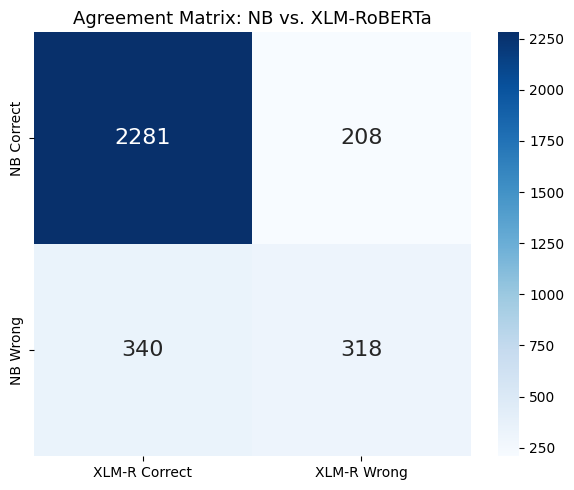

✓ Saved to /content/drive/MyDrive/3rd Year 2nd Term/Machine Learning - CS ELEC 2C /ML - Repo 5/Finals Project/taglish-project/outputs/figures/agreement_matrix.png


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Merge into one DataFrame
comp = pd.DataFrame({
    'text':        nb_df['text'],
    'true_label':  nb_df['true_label'],
    'nb_pred':     nb_df['nb_pred'],
    'xlmr_pred':   xlmr_df['xlmr_pred'],
    'nb_correct':  nb_df['nb_correct'],
    'xlmr_correct': xlmr_df['xlmr_correct'],
})

# Agreement categories
both_correct = ((comp['nb_correct'] == 1) & (comp['xlmr_correct'] == 1)).sum()
nb_only      = ((comp['nb_correct'] == 1) & (comp['xlmr_correct'] == 0)).sum()
xlmr_only    = ((comp['nb_correct'] == 0) & (comp['xlmr_correct'] == 1)).sum()
both_wrong   = ((comp['nb_correct'] == 0) & (comp['xlmr_correct'] == 0)).sum()

print("Agreement Matrix:")
print(f"  Both Correct:  {both_correct}  ({both_correct/len(comp)*100:.1f}%)")
print(f"  NB Only:       {nb_only}  ({nb_only/len(comp)*100:.1f}%)")
print(f"  XLM-R Only:    {xlmr_only}  ({xlmr_only/len(comp)*100:.1f}%)")
print(f"  Both Wrong:    {both_wrong}  ({both_wrong/len(comp)*100:.1f}%)")

# Visualize as heatmap
agreement = np.array([[both_correct, nb_only],
                       [xlmr_only, both_wrong]])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(agreement, annot=True, fmt='d', cmap='Blues',
            xticklabels=['XLM-R Correct', 'XLM-R Wrong'],
            yticklabels=['NB Correct', 'NB Wrong'],
            ax=ax, annot_kws={'size': 16})
ax.set_title('Agreement Matrix: NB vs. XLM-RoBERTa', fontsize=13)
plt.tight_layout()

save_path = f"{FIGURES}/agreement_matrix.png"
fig.savefig(save_path, dpi=150)
plt.show()
print(f"✓ Saved to {save_path}")

## 2. McNemar's Test
Tests whether the two models have statistically different error rates on the same test set.  
Uses the off-diagonal cells of the agreement matrix (NB Only vs. XLM-R Only).  
- **H₀:** NB and XLM-R have equivalent classification performance.  
- **H₁:** XLM-R has statistically superior classification performance.  
- α = 0.05

In [5]:
from scipy.stats import chi2

# McNemar's test using the off-diagonal cells
# b = NB correct, XLM-R wrong (nb_only)
# c = NB wrong, XLM-R correct (xlmr_only)
b = nb_only
c = xlmr_only

# McNemar's chi-squared statistic (with continuity correction)
if b + c == 0:
    print("No discordant pairs — models agree on every prediction.")
    mcnemar_stat = 0
    p_value = 1.0
else:
    mcnemar_stat = (abs(b - c) - 1)**2 / (b + c)
    p_value = 1 - chi2.cdf(mcnemar_stat, df=1)

print("=" * 55)
print("McNemar's Test: NB vs. XLM-RoBERTa")
print("=" * 55)
print(f"  Discordant cells:")
print(f"    NB correct, XLM-R wrong (b): {b}")
print(f"    NB wrong, XLM-R correct (c): {c}")
print(f"  Chi² statistic: {mcnemar_stat:.4f}")
print(f"  p-value:        {p_value:.6f}")
print(f"  α:              0.05")
print(f"  Decision:       {'Reject H₀' if p_value < 0.05 else 'Fail to reject H₀'}")
print()

if p_value < 0.05:
    if c > b:
        print("  → XLM-R is statistically significantly better than NB.")
    else:
        print("  → NB is statistically significantly better than XLM-R.")
else:
    print("  → No statistically significant difference between the two models.")

# Also run scipy's built-in mcnemar for verification
from scipy.stats import contingency

# Build the 2x2 contingency table
table = np.array([[both_correct, nb_only],
                   [xlmr_only, both_wrong]])

# Use exact=False for chi-squared version (matches our manual calc)
try:
    from statsmodels.stats.contingency_tables import mcnemar as mcnemar_test
    result = mcnemar_test(table, exact=False, correction=True)
    print(f"\n  Verification (statsmodels): stat={result.statistic:.4f}, p={result.pvalue:.6f}")
except ImportError:
    print("\n  (statsmodels not available for verification — manual calculation used)")

McNemar's Test: NB vs. XLM-RoBERTa
  Discordant cells:
    NB correct, XLM-R wrong (b): 208
    NB wrong, XLM-R correct (c): 340
  Chi² statistic: 31.3157
  p-value:        0.000000
  α:              0.05
  Decision:       Reject H₀

  → XLM-R is statistically significantly better than NB.

  Verification (statsmodels): stat=31.3157, p=0.000000


## 3. Side-by-Side Metrics Comparison
Full metrics table: accuracy, weighted F1, per-class P/R/F1 for both models.

Full Metrics Comparison: NB vs. XLM-RoBERTa
            Metric Naive Bayes XLM-RoBERTa
          Accuracy      0.7909      0.8329
       Weighted F1      0.7928      0.8335
                                          
Negative Precision      0.8165      0.8612
   Negative Recall      0.7624      0.8335
       Negative F1      0.7885      0.8471
 Neutral Precision      0.6891      0.7533
    Neutral Recall      0.7645      0.7866
        Neutral F1      0.7248      0.7696
Positive Precision      0.8910      0.8939
   Positive Recall      0.8470      0.8809
       Positive F1      0.8685      0.8874


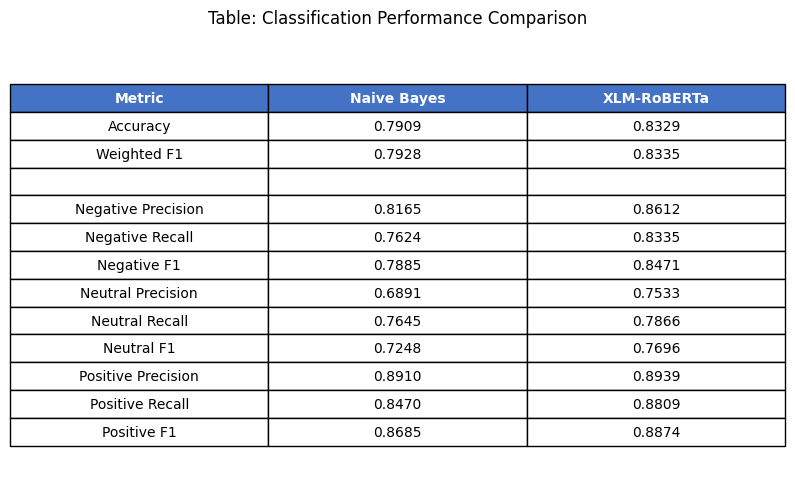

✓ Saved to /content/drive/MyDrive/3rd Year 2nd Term/Machine Learning - CS ELEC 2C /ML - Repo 5/Finals Project/taglish-project/outputs/figures/final_comparison_table.png


In [6]:
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, classification_report

label_names = ['Negative', 'Neutral', 'Positive']

# NB metrics
nb_acc = accuracy_score(comp['true_label'], comp['nb_pred'])
nb_f1w = f1_score(comp['true_label'], comp['nb_pred'], average='weighted')
nb_p, nb_r, nb_f1, _ = precision_recall_fscore_support(comp['true_label'], comp['nb_pred'], average=None)

# XLM-R metrics
xlmr_acc = accuracy_score(comp['true_label'], comp['xlmr_pred'])
xlmr_f1w = f1_score(comp['true_label'], comp['xlmr_pred'], average='weighted')
xlmr_p, xlmr_r, xlmr_f1, _ = precision_recall_fscore_support(comp['true_label'], comp['xlmr_pred'], average=None)

# Build comparison table
metrics_data = {
    'Metric': [
        'Accuracy', 'Weighted F1', '',
        'Negative Precision', 'Negative Recall', 'Negative F1',
        'Neutral Precision', 'Neutral Recall', 'Neutral F1',
        'Positive Precision', 'Positive Recall', 'Positive F1',
    ],
    'Naive Bayes': [
        f'{nb_acc:.4f}', f'{nb_f1w:.4f}', '',
        f'{nb_p[0]:.4f}', f'{nb_r[0]:.4f}', f'{nb_f1[0]:.4f}',
        f'{nb_p[1]:.4f}', f'{nb_r[1]:.4f}', f'{nb_f1[1]:.4f}',
        f'{nb_p[2]:.4f}', f'{nb_r[2]:.4f}', f'{nb_f1[2]:.4f}',
    ],
    'XLM-RoBERTa': [
        f'{xlmr_acc:.4f}', f'{xlmr_f1w:.4f}', '',
        f'{xlmr_p[0]:.4f}', f'{xlmr_r[0]:.4f}', f'{xlmr_f1[0]:.4f}',
        f'{xlmr_p[1]:.4f}', f'{xlmr_r[1]:.4f}', f'{xlmr_f1[1]:.4f}',
        f'{xlmr_p[2]:.4f}', f'{xlmr_r[2]:.4f}', f'{xlmr_f1[2]:.4f}',
    ],
}

metrics_table = pd.DataFrame(metrics_data)
print("=" * 55)
print("Full Metrics Comparison: NB vs. XLM-RoBERTa")
print("=" * 55)
print(metrics_table.to_string(index=False))

# Save as figure
fig, ax = plt.subplots(figsize=(8, 5))
ax.axis('off')
table_plot = ax.table(
    cellText=metrics_table.values,
    colLabels=metrics_table.columns,
    cellLoc='center',
    loc='center',
)
table_plot.auto_set_font_size(False)
table_plot.set_fontsize(10)
table_plot.scale(1.2, 1.5)

# Style header
for j in range(len(metrics_table.columns)):
    table_plot[0, j].set_facecolor('#4472C4')
    table_plot[0, j].set_text_props(color='white', fontweight='bold')

ax.set_title('Table: Classification Performance Comparison', fontsize=12, pad=20)
plt.tight_layout()

save_path = f"{FIGURES}/final_comparison_table.png"
fig.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved to {save_path}")

## 4. Phenomenon-Sliced Error Analysis
The centerpiece of RQ4: compute per-slice accuracy for both models  
to identify which linguistic phenomena each model handles better or worse.

Slices from Data Person:
- Pragmatic markers: naman, lang, pa, na
- Slang: awit
- Negation: hindi, di, wala
- Short reviews (<10 tokens) / Long reviews (>50 tokens)
- Code-switching density: high_cs / low_cs

In [7]:
# Load phenomenon slices
slices_df = pd.read_csv(f"{OUTPUTS}/phenomenon_slices.csv")

# Rename columns to match predictions files
slices_df = slices_df.rename(columns={'review': 'text', 'label': 'true_label'})

print(f"Phenomenon slices loaded: {len(slices_df)} rows")
print(f"Slices: {slices_df['slice_name'].unique()}")
print(f"Reviews per slice:")
print(slices_df['slice_name'].value_counts())

Phenomenon slices loaded: 8360 rows
Slices: ['marker_naman' 'marker_lang' 'marker_pa' 'marker_na' 'slang_awit'
 'negation_hindi' 'negation_di' 'negation_wala' 'short_reviews'
 'long_reviews' 'high_cs' 'low_cs']
Reviews per slice:
slice_name
high_cs           3050
marker_na         1427
marker_lang        899
marker_naman       765
marker_pa          554
negation_hindi     543
negation_di        440
short_reviews      256
negation_wala      213
long_reviews       111
low_cs              97
slang_awit           5
Name: count, dtype: int64


In [8]:
# Merge predictions with slices
# A review can appear in multiple slices, so we merge on text + true_label
slices_with_preds = slices_df.merge(
    comp[['text', 'nb_pred', 'xlmr_pred', 'nb_correct', 'xlmr_correct']],
    on='text',
    how='inner'
)

unmatched = len(slices_df) - len(slices_with_preds)
if unmatched > 0:
    print(f"⚠ {unmatched} slice rows did not match a prediction row (possibly train-set reviews).")
    print(f"  Matched: {len(slices_with_preds)} / {len(slices_df)}")
else:
    print(f"✓ All {len(slices_with_preds)} slice rows matched.")

# Compute per-slice metrics
slice_results = []

for slice_name in sorted(slices_with_preds['slice_name'].unique()):
    subset = slices_with_preds[slices_with_preds['slice_name'] == slice_name]
    n = len(subset)
    nb_acc = subset['nb_correct'].mean()
    xlmr_acc = subset['xlmr_correct'].mean()
    diff = xlmr_acc - nb_acc

    slice_results.append({
        'Slice': slice_name,
        'N': n,
        'NB Accuracy': f'{nb_acc:.4f}',
        'XLM-R Accuracy': f'{xlmr_acc:.4f}',
        'Δ (XLM-R − NB)': f'{diff:+.4f}',
        'nb_acc_raw': nb_acc,
        'xlmr_acc_raw': xlmr_acc,
    })

slice_table = pd.DataFrame(slice_results)

# Add overall row for reference
overall_nb = comp['nb_correct'].mean()
overall_xlmr = comp['xlmr_correct'].mean()
overall_row = pd.DataFrame([{
    'Slice': '** OVERALL **',
    'N': len(comp),
    'NB Accuracy': f'{overall_nb:.4f}',
    'XLM-R Accuracy': f'{overall_xlmr:.4f}',
    'Δ (XLM-R − NB)': f'{overall_xlmr - overall_nb:+.4f}',
    'nb_acc_raw': overall_nb,
    'xlmr_acc_raw': overall_xlmr,
}])

slice_table_display = pd.concat([slice_table, overall_row], ignore_index=True)

print("\n" + "=" * 75)
print("Phenomenon-Sliced Accuracy: NB vs. XLM-RoBERTa")
print("=" * 75)
print(slice_table_display[['Slice', 'N', 'NB Accuracy', 'XLM-R Accuracy', 'Δ (XLM-R − NB)']].to_string(index=False))

✓ All 8360 slice rows matched.

Phenomenon-Sliced Accuracy: NB vs. XLM-RoBERTa
         Slice    N NB Accuracy XLM-R Accuracy Δ (XLM-R − NB)
       high_cs 3050      0.7898         0.8305        +0.0407
  long_reviews  111      0.7658         0.8018        +0.0360
        low_cs   97      0.8247         0.9072        +0.0825
   marker_lang  899      0.7753         0.8142        +0.0389
     marker_na 1427      0.7926         0.8192        +0.0266
  marker_naman  765      0.7712         0.8092        +0.0379
     marker_pa  554      0.7924         0.8394        +0.0469
   negation_di  440      0.7523         0.8250        +0.0727
negation_hindi  543      0.7256         0.7882        +0.0626
 negation_wala  213      0.7981         0.8357        +0.0376
 short_reviews  256      0.7969         0.8594        +0.0625
    slang_awit    5      0.6000         1.0000        +0.4000
 ** OVERALL ** 3147      0.7909         0.8329        +0.0419


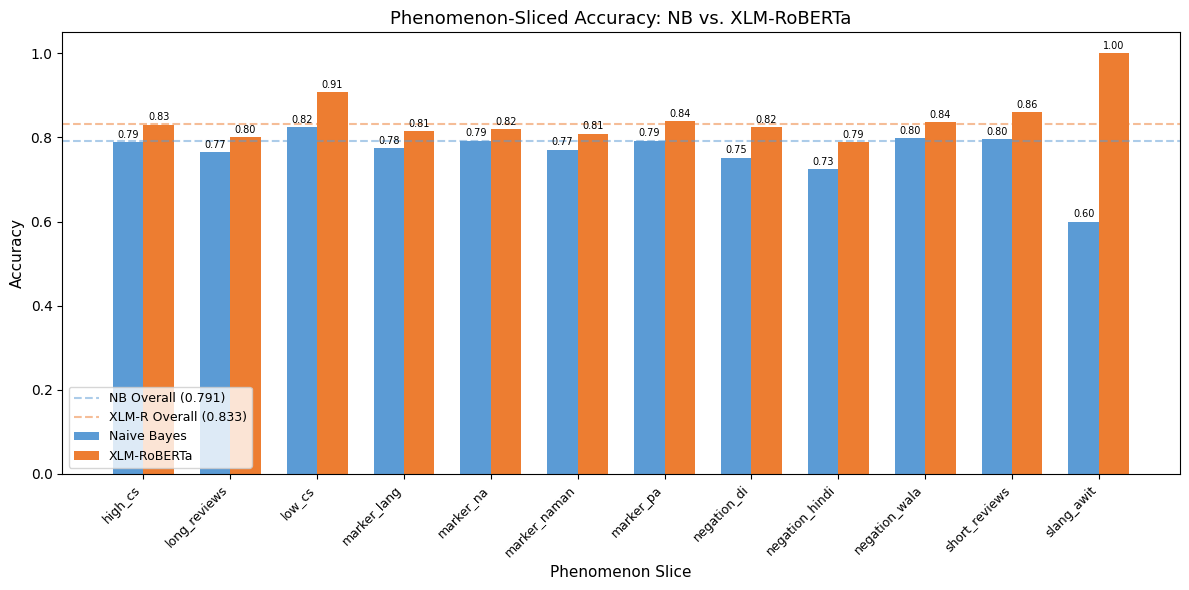

✓ Saved to /content/drive/MyDrive/3rd Year 2nd Term/Machine Learning - CS ELEC 2C /ML - Repo 5/Finals Project/taglish-project/outputs/figures/phenomenon_slice_comparison.png


In [9]:
# Bar chart comparing NB vs XLM-R accuracy per slice
slice_plot = slice_table.copy()  # Without the overall row

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(slice_plot))
width = 0.35

bars_nb   = ax.bar(x - width/2, slice_plot['nb_acc_raw'],   width, label='Naive Bayes', color='#5B9BD5')
bars_xlmr = ax.bar(x + width/2, slice_plot['xlmr_acc_raw'], width, label='XLM-RoBERTa', color='#ED7D31')

# Add overall accuracy as reference lines
ax.axhline(y=overall_nb,   color='#5B9BD5', linestyle='--', alpha=0.5, label=f'NB Overall ({overall_nb:.3f})')
ax.axhline(y=overall_xlmr, color='#ED7D31', linestyle='--', alpha=0.5, label=f'XLM-R Overall ({overall_xlmr:.3f})')

ax.set_xlabel('Phenomenon Slice', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Phenomenon-Sliced Accuracy: NB vs. XLM-RoBERTa', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(slice_plot['Slice'], rotation=45, ha='right', fontsize=9)
ax.legend(loc='lower left', fontsize=9)
ax.set_ylim(0, 1.05)

# Add value labels on bars
for bar in bars_nb:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=7)
for bar in bars_xlmr:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=7)

plt.tight_layout()

save_path = f"{FIGURES}/phenomenon_slice_comparison.png"
fig.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved to {save_path}")

## 5. Error Pattern Deep Dive
Examine the "Both Wrong" and "Model-specific error" cases  
to understand qualitative failure patterns.

In [10]:
# Tag each review with its agreement category
comp['agreement'] = 'both_correct'
comp.loc[(comp['nb_correct'] == 1) & (comp['xlmr_correct'] == 0), 'agreement'] = 'nb_only'
comp.loc[(comp['nb_correct'] == 0) & (comp['xlmr_correct'] == 1), 'agreement'] = 'xlmr_only'
comp.loc[(comp['nb_correct'] == 0) & (comp['xlmr_correct'] == 0), 'agreement'] = 'both_wrong'

label_names = ['Negative', 'Neutral', 'Positive']

# Show class breakdown of each agreement category
print("Class distribution within each agreement category:")
print("=" * 60)
for cat in ['nb_only', 'xlmr_only', 'both_wrong']:
    subset = comp[comp['agreement'] == cat]
    print(f"\n{cat.upper()} ({len(subset)} reviews):")
    for lbl in [0, 1, 2]:
        count = (subset['true_label'] == lbl).sum()
        print(f"  {label_names[lbl]}: {count} ({count/len(subset)*100:.1f}%)")

# Sample reviews from each category
print("\n" + "=" * 60)
print("Sample reviews — NB CORRECT, XLM-R WRONG:")
print("=" * 60)
nb_only_samples = comp[comp['agreement'] == 'nb_only'].sample(min(5, nb_only), random_state=42)
for _, row in nb_only_samples.iterrows():
    print(f"  True: {label_names[row['true_label']]} | NB: {label_names[row['nb_pred']]} | XLM-R: {label_names[row['xlmr_pred']]}")
    print(f"  \"{row['text'][:120]}...\"")
    print()

print("=" * 60)
print("Sample reviews — XLM-R CORRECT, NB WRONG:")
print("=" * 60)
xlmr_only_samples = comp[comp['agreement'] == 'xlmr_only'].sample(min(5, xlmr_only), random_state=42)
for _, row in xlmr_only_samples.iterrows():
    print(f"  True: {label_names[row['true_label']]} | NB: {label_names[row['nb_pred']]} | XLM-R: {label_names[row['xlmr_pred']]}")
    print(f"  \"{row['text'][:120]}...\"")
    print()

print("=" * 60)
print("Sample reviews — BOTH WRONG:")
print("=" * 60)
both_wrong_samples = comp[comp['agreement'] == 'both_wrong'].sample(min(5, both_wrong), random_state=42)
for _, row in both_wrong_samples.iterrows():
    print(f"  True: {label_names[row['true_label']]} | NB: {label_names[row['nb_pred']]} | XLM-R: {label_names[row['xlmr_pred']]}")
    print(f"  \"{row['text'][:120]}...\"")
    print()

Class distribution within each agreement category:

NB_ONLY (208 reviews):
  Negative: 73 (35.1%)
  Neutral: 100 (48.1%)
  Positive: 35 (16.8%)

XLMR_ONLY (340 reviews):
  Negative: 146 (42.9%)
  Neutral: 124 (36.5%)
  Positive: 70 (20.6%)

BOTH_WRONG (318 reviews):
  Negative: 98 (30.8%)
  Neutral: 132 (41.5%)
  Positive: 88 (27.7%)

Sample reviews — NB CORRECT, XLM-R WRONG:
  True: Neutral | NB: Neutral | XLM-R: Positive
  "fast shipment in just 3days naka rating agad na biliran province from manila ito lang muna rate ko for now i ll have to ..."

  True: Neutral | NB: Neutral | XLM-R: Negative
  "lots of dents on the actual product itself makes ice though didnt want to return kasi tagal ako naghintay..."

  True: Positive | NB: Positive | XLM-R: Neutral
  "the product is good medyo manipis lang well packaged mabilis naship this shop is recommended..."

  True: Negative | NB: Negative | XLM-R: Neutral
  "free wifi pero napaka bagal walang kwenta internet connection dito..."

  True: 

## 6. Cost & Efficiency Comparison
Training time, model size, inference speed, interpretability — the practical trade-offs (RQ4d).

Cost & Efficiency Comparison
           Metric                           Naive Bayes                       XLM-RoBERTa
    Training time                           < 5 seconds                      ~3.8 minutes
Model size (disk)              < 10 MB (TF-IDF + model)              ~1.1 GB (full model)
       Parameters                V features × 3 classes                             ~278M
     Requires GPU                         No (CPU only)                    Yes (Tesla T4)
 Interpretability High (top features directly readable) Low (requires attention analysis)


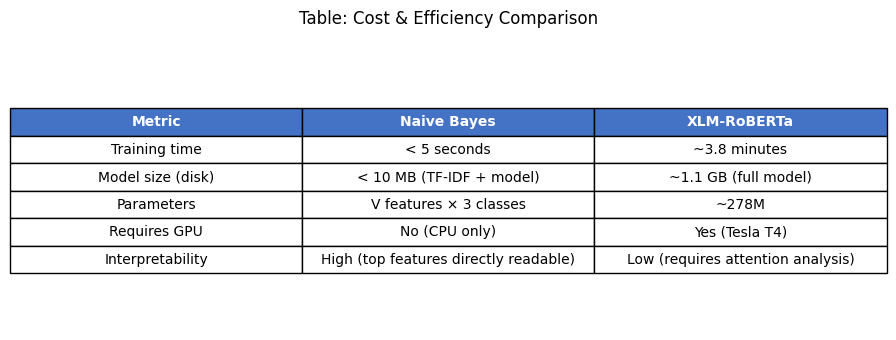

✓ Saved to /content/drive/MyDrive/3rd Year 2nd Term/Machine Learning - CS ELEC 2C /ML - Repo 5/Finals Project/taglish-project/outputs/figures/cost_comparison.png


In [11]:
import json

# Load XLM-R metadata
with open(f"{OUTPUTS}/xlmr_training_metadata.json", 'r') as f:
    xlmr_meta = json.load(f)

# NB training is near-instant; estimate from typical runs
# (NB person can update these if they logged exact times)
cost_data = {
    'Metric': [
        'Training time',
        'Model size (disk)',
        'Parameters',
        'Requires GPU',
        'Interpretability',
    ],
    'Naive Bayes': [
        '< 5 seconds',
        '< 10 MB (TF-IDF + model)',
        'V features × 3 classes',
        'No (CPU only)',
        'High (top features directly readable)',
    ],
    'XLM-RoBERTa': [
        f'~{xlmr_meta.get("training_time_minutes", "N/A")} minutes',
        '~1.1 GB (full model)',
        '~278M',
        f'Yes ({xlmr_meta.get("gpu_name", "T4 GPU")})',
        'Low (requires attention analysis)',
    ],
}

cost_table = pd.DataFrame(cost_data)
print("=" * 65)
print("Cost & Efficiency Comparison")
print("=" * 65)
print(cost_table.to_string(index=False))

# Save as figure
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.axis('off')
table_plot = ax.table(
    cellText=cost_table.values,
    colLabels=cost_table.columns,
    cellLoc='center',
    loc='center',
)
table_plot.auto_set_font_size(False)
table_plot.set_fontsize(10)
table_plot.scale(1.2, 1.6)

for j in range(len(cost_table.columns)):
    table_plot[0, j].set_facecolor('#4472C4')
    table_plot[0, j].set_text_props(color='white', fontweight='bold')

ax.set_title('Table: Cost & Efficiency Comparison', fontsize=12, pad=20)
plt.tight_layout()

save_path = f"{FIGURES}/cost_comparison.png"
fig.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved to {save_path}")

## 7. Summary of Findings

Key results to carry into the manuscript:
1. **Overall performance gap:** NB vs XLM-R accuracy and F1
2. **McNemar's test:** statistically significant difference?
3. **Phenomenon slices:** which slices show the largest/smallest gap?
4. **Agreement patterns:** what fraction of reviews do both models get right/wrong?
5. **Cost trade-off:** orders-of-magnitude difference in compute for how much accuracy?

In [12]:
print("=" * 65)
print("NOTEBOOK 04 — RESULTS SUMMARY FOR MANUSCRIPT")
print("=" * 65)

print(f"\n1. OVERALL PERFORMANCE")
print(f"   NB Accuracy:     {overall_nb:.4f}")
print(f"   XLM-R Accuracy:  {overall_xlmr:.4f}")
print(f"   Δ:               {overall_xlmr - overall_nb:+.4f}")

print(f"\n2. McNEMAR'S TEST")
print(f"   Chi²: {mcnemar_stat:.4f}   p = {p_value:.6f}")
print(f"   Decision: {'Reject H₀ — significant difference' if p_value < 0.05 else 'Fail to reject H₀'}")

print(f"\n3. AGREEMENT MATRIX")
print(f"   Both correct:  {both_correct} ({both_correct/len(comp)*100:.1f}%)")
print(f"   NB only:       {nb_only} ({nb_only/len(comp)*100:.1f}%)")
print(f"   XLM-R only:    {xlmr_only} ({xlmr_only/len(comp)*100:.1f}%)")
print(f"   Both wrong:    {both_wrong} ({both_wrong/len(comp)*100:.1f}%)")

print(f"\n4. PHENOMENON SLICES — LARGEST XLM-R ADVANTAGE")
slice_table_sorted = slice_table.copy()
slice_table_sorted['diff'] = slice_table_sorted['xlmr_acc_raw'] - slice_table_sorted['nb_acc_raw']
for _, row in slice_table_sorted.nlargest(3, 'diff').iterrows():
    print(f"   {row['Slice']:20s}  NB={row['nb_acc_raw']:.3f}  XLM-R={row['xlmr_acc_raw']:.3f}  Δ={row['diff']:+.3f}")

print(f"\n   SMALLEST GAP (or NB advantage)")
for _, row in slice_table_sorted.nsmallest(3, 'diff').iterrows():
    print(f"   {row['Slice']:20s}  NB={row['nb_acc_raw']:.3f}  XLM-R={row['xlmr_acc_raw']:.3f}  Δ={row['diff']:+.3f}")

print(f"\n5. FILES SAVED")
print(f"   {FIGURES}/agreement_matrix.png")
print(f"   {FIGURES}/phenomenon_slice_comparison.png")
print(f"   {FIGURES}/final_comparison_table.png")
print(f"   {FIGURES}/cost_comparison.png")

NOTEBOOK 04 — RESULTS SUMMARY FOR MANUSCRIPT

1. OVERALL PERFORMANCE
   NB Accuracy:     0.7909
   XLM-R Accuracy:  0.8329
   Δ:               +0.0419

2. McNEMAR'S TEST
   Chi²: 31.3157   p = 0.000000
   Decision: Reject H₀ — significant difference

3. AGREEMENT MATRIX
   Both correct:  2281 (72.5%)
   NB only:       208 (6.6%)
   XLM-R only:    340 (10.8%)
   Both wrong:    318 (10.1%)

4. PHENOMENON SLICES — LARGEST XLM-R ADVANTAGE
   slang_awit            NB=0.600  XLM-R=1.000  Δ=+0.400
   low_cs                NB=0.825  XLM-R=0.907  Δ=+0.082
   negation_di           NB=0.752  XLM-R=0.825  Δ=+0.073

   SMALLEST GAP (or NB advantage)
   marker_na             NB=0.793  XLM-R=0.819  Δ=+0.027
   long_reviews          NB=0.766  XLM-R=0.802  Δ=+0.036
   negation_wala         NB=0.798  XLM-R=0.836  Δ=+0.038

5. FILES SAVED
   /content/drive/MyDrive/3rd Year 2nd Term/Machine Learning - CS ELEC 2C /ML - Repo 5/Finals Project/taglish-project/outputs/figures/agreement_matrix.png
   /content/d

## Day 3 Notebook Status
- [x] Agreement matrix built and visualized
- [x] McNemar's test complete
- [x] Side-by-side metrics comparison table
- [x] Phenomenon-sliced accuracy analysis (12 slices)
- [x] Error pattern deep dive (samples from each agreement category)
- [x] Cost & efficiency comparison
- [x] All figures saved to Drive

**Next:** Use these results to write the Comparison Results, Discussion, Conclusion, and Abstract in the manuscript.